In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

# --- Third-party imports ---
from lifelines.utils import concordance_index

from sksurv.metrics import cumulative_dynamic_auc
from sksurv.util import Surv

from sklearn.metrics import brier_score_loss


In [ ]:
beta_sj = pd.read_csv("data/beta_sjmb03_20240104.csv", header = None)
cnv_sj = pd.read_csv("data/CNV_gene_sjmb03_20240111.csv", header = None)
surv_sj = pd.read_csv("/hovestadtlab/sabina/methylation-survival/full_metadata/SJMB03_full_tab.csv")

surv_sj_df = pd.read_csv('data/sjmb03_surv.csv')

In [33]:
surv_sj_df = pd.read_csv('data/sjmb03_surv.csv')

In [34]:
surv_sj_high = surv_sj_df[surv_sj["risk_final"].eq("High")]

In [ ]:
beta_sj_high = beta_sj.iloc[:, surv_sj["risk_final"].eq("High").to_numpy()]
cnv_sj_high = cnv_sj.iloc[:, surv_sj["risk_final"].eq("High").to_numpy()]
surv_sj_high = surv_sj_df[surv_sj["risk_final"].eq("High")]

beta_sj_high.to_csv("beta_sj_high.csv", index=False, header=False)
cnv_sj_high.to_csv("cnv_sj_high.csv", index=False, header=False)
surv_sj_high.to_csv("surv_sj_high.csv")

In [ ]:
beta_sj_average = beta_sj.iloc[:, surv_sj["risk_final"].eq("Average").to_numpy()]
cnv_sj_average = cnv_sj.iloc[:, surv_sj["risk_final"].eq("Average").to_numpy()]
surv_sj_average = surv_sj_df[surv_sj["risk_final"].eq("Average")]

beta_sj_average.to_csv("beta_sj_average.csv", index=False, header=False)
cnv_sj_average.to_csv("cnv_sj_average.csv", index=False, header=False)
surv_sj_average.to_csv("surv_sj_average.csv")

In [ ]:
surv_sj_high.to_csv("surv_sj_high.csv")
surv_sj_average.to_csv("surv_sj_average.csv")

In [2]:
surv_sturm = pd.read_csv('/hovestadtlab/sabina/methylation-survival/data/surv_sturm.csv')
surv_pred_sturm = pd.read_csv('/hovestadtlab/sabina/methylation-survival/results/survival_predictions.csv')

In [56]:
acns331_meta = pd.read_csv('/hovestadtlab/sabina/methylation-survival/full_metadata/acns331_clinical_include.csv')
acns331_surv = pd.read_csv('/hovestadtlab/sabina/methylation-survival/data/acns331_surv.csv')
acns331_pred = pd.read_csv('/hovestadtlab/sabina/methylation-survival/results/acns331_predictions.csv')
acns331_pred.set_index('Patient_ID', inplace=True) 
sdcsi = acns331_meta.CSIgroup == "SDCSI"

In [57]:
sjmb03_meta = pd.read_csv('/hovestadtlab/sabina/methylation-survival/full_metadata/SJMB03_full_tab.csv')
sjmb03_pred = pd.read_csv('/hovestadtlab/sabina/methylation-survival/results/sjmb03_predictions.csv')
sjmb03_pred.set_index('Patient_ID', inplace=True) 
time_bins = [0.019167, 0.33333, 0.5847, 0.75, 0.94167, 1.1667, 1.5, 1.8333, 2.0833, 2.5833, 3.25, 3.9, 5.6667, 8.2875, 22.0]
sjmb03_surv = pd.read_csv('/hovestadtlab/sabina/methylation-survival/data/sjmb03_surv.csv')
sjmb03_surv.set_index('Patient_ID', inplace=True)

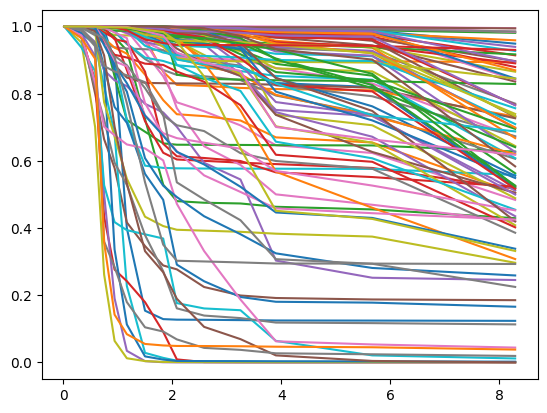

In [17]:
high_risk = sjmb03_meta.risk_final == 'High'
average_risk = sjmb03_meta.risk_final == 'Average'
plt.plot(time_bins[0:-1],np.asarray(sjmb03_pred.values[high_risk,][:,0:-2].T))
plt.show()

In [58]:
# --- 5. Prepare Time Points ---
test_samples = sjmb03_pred.values #[high_risk,]
t_test_np = sjmb03_meta['os_time_yrs'].values #[high_risk]
e_test_np = sjmb03_meta['os (0=censored, 1=event)'].values #[high_risk]

test_samples = acns331_pred.values #[high_risk,]
t_test_np = acns331_surv['time'].values #[high_risk]
e_test_np = acns331_surv['event'].values #[high_risk]

test_samples = np.concatenate([
    sjmb03_pred.values,
    acns331_pred.values
], axis=0)

t_test_np = np.concatenate([
    sjmb03_meta['os_time_yrs'].values,
    acns331_surv['time'].values
], axis=0)

e_test_np = np.concatenate([
    sjmb03_meta['os (0=censored, 1=event)'].values,
    acns331_surv['event'].values
], axis=0)

n_test_samples = test_samples.shape[0]
pred_times = np.concatenate(([0.0], time_bins))
eval_times = np.arange(0.1, 10.01, 0.1)


interpolated_probs = np.zeros((n_test_samples, len(eval_times)))
for i in range(n_test_samples):
    y_interp = test_samples[i, :]
    interp_func = interp1d(pred_times, y_interp, kind='linear', bounds_error=False, fill_value=(y_interp[0], y_interp[-1]))
    interpolated_probs[i, :] = interp_func(eval_times)

interpolated_probs = np.clip(interpolated_probs, 0.0, 1.0)

# --- 6b. Apply Smoothing
window = 10
kernel = np.ones(window) / window
pad_left = window // 2
pad_right = window - pad_left - 1
smoothed_interpolated_probs = np.zeros_like(interpolated_probs)

for i in range(n_test_samples):
    y = interpolated_probs[i, :]
    if np.isnan(y).any():
        smoothed_interpolated_probs[i, :] = np.nan
        continue
    y_padded = np.pad(y, (pad_left, pad_right), mode='reflect')
    y_conv = np.convolve(y_padded, kernel, mode='valid')
    y_mon = np.minimum.accumulate(y_conv)
    smoothed_interpolated_probs[i, :] = np.clip(y_mon, 0.0, 1.0)

# --- 7. Calculate Concordance Index (C-index) ---
print("\n--- Calculating C-index ---")
eval_time_cindex = 5.0; c_index = np.nan
idx_cindex = np.abs(eval_times - min(max(eval_times.min(), eval_time_cindex), eval_times.max())).argmin()

if idx_cindex < smoothed_interpolated_probs.shape[1]:
    probs_for_cindex = smoothed_interpolated_probs[:, idx_cindex]
    valid_mask_c1 = ~np.isnan(probs_for_cindex)
    if np.any(valid_mask_c1):
        risk_scores_cindex = -probs_for_cindex[valid_mask_c1] 
        t_test_c = t_test_np[valid_mask_c1]
        e_test_c = e_test_np[valid_mask_c1]
        try: c_index = concordance_index(t_test_c, -risk_scores_cindex, e_test_c.astype(bool))
        except Exception as e: print(f"Error C-index: {e}")
        print(f"C-index: {c_index:.4f}")
    else: print("Warning: All survival probs at t~5 NaN. Cannot calc C-index.")



--- Calculating C-index ---
C-index: 0.7521


In [59]:
ac_g34 = (acns331_meta.SubgroupForTable1 == "MB,G3") | (acns331_meta.SubgroupForTable1 == "MB,G4")
sj_g34 = (sjmb03_meta.Final_subgroup == "MB,_G3") | (sjmb03_meta.Final_subgroup == "MB,_G4")

g34 = np.concatenate([  sj_g34, ac_g34], axis=0)

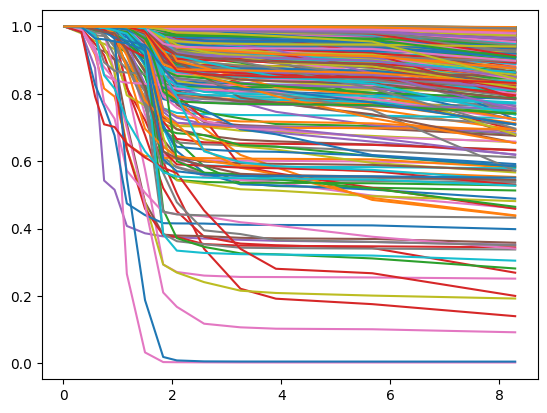

In [60]:
plt.plot(time_bins[0:-1],np.asarray(acns331_pred.values[:,0:-2].T))
plt.show()

In [40]:

# g = high_risk
# g = average_risk
g = sdcsi
c_index = concordance_index(t_test_np[g], interpolated_probs[:,51][g], e_test_np[g].astype(bool))
print(f"C-index: {c_index:.4f}")



C-index: 0.7563


In [61]:

test_samples = np.concatenate([
    sjmb03_pred.values,
    acns331_pred.values
], axis=0)

t_test_np = np.concatenate([
    sjmb03_meta['os_time_yrs'].values,
    acns331_surv['time'].values
], axis=0)

e_test_np = np.concatenate([
    sjmb03_meta['os (0=censored, 1=event)'].values,
    acns331_surv['event'].values
], axis=0)

In [62]:
g34 = np.concatenate([  sj_g34, ac_g34], axis=0)
c_index = concordance_index(t_test_np[g34], interpolated_probs[g34,51], e_test_np[g34].astype(bool))
print(f"C-index: {c_index:.4f}")

C-index: 0.7204


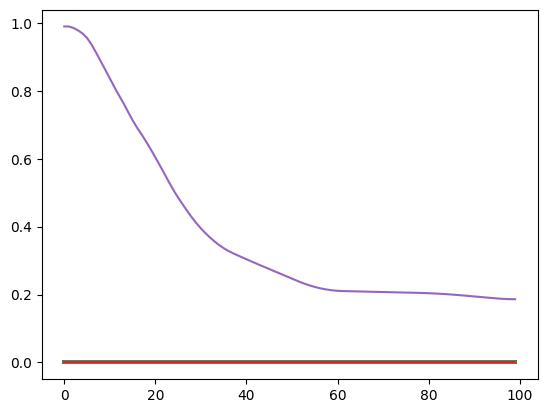

In [61]:
plt.plot(smoothed_interpolated_probs.T)
plt.show()

In [ ]:
surv_pred_sturm.set_index('Patient_ID', inplace=True) 
surv_sturm.set_index('Patient_ID', inplace=True)

,Patient_ID,S_t_0.0000,S_t_0.0192,S_t_0.3333,S_t_0.5847,S_t_0.7500,S_t_0.9417,S_t_1.1667,S_t_1.5000,S_t_1.8333,S_t_2.0833,S_t_2.5833,S_t_3.2500,S_t_3.9000,S_t_5.6667,S_t_8.2875,S_t_22.0000
0,ICGC_MB1,1.0,0.999995,0.999963,0.999880,0.999841,0.999498,0.990016,0.968509,0.825170,0.776704,0.757359,0.733249,0.725114,0.704987,0.664618,0.090717
1,ICGC_MB2,1.0,0.999940,0.999602,0.996254,0.995089,0.993054,0.982275,0.971664,0.947891,0.931742,0.880272,0.759806,0.727501,0.526045,0.442812,0.042622
2,ICGC_MB3,1.0,1.000000,0.999999,0.999995,0.999992,0.999983,0.999909,0.999596,0.995295,0.986152,0.969290,0.944466,0.940679,0.915758,0.843107,0.073241
3,ICGC_MB5,1.0,0.999988,0.999918,0.998839,0.998190,0.996971,0.989291,0.981495,0.969448,0.960994,0.940236,0.906095,0.896211,0.834914,0.798456,0.155375
4,ICGC_MB6,1.0,0.996452,0.982299,0.947044,0.938807,0.927112,0.915625,0.892782,0.754358,0.742921,0.735705,0.681046,0.627025,0.579742,0.576616,0.150046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,MB_Exm702,1.0,0.948470,0.591216,0.231263,0.189714,0.173355,0.160278,0.152399,0.133676,0.132322,0.131225,0.127461,0.119810,0.104663,0.103530,0.029741
96,MB_Exm704,1.0,0.993527,0.955346,0.857337,0.843219,0.831730,0.820305,0.797870,0.682189,0.673062,0.663660,0.625365,0.580321,0.487378,0.482258,0.112066
97,MB_Exm879,1.0,0.998153,0.988482,0.967139,0.962163,0.958979,0.954185,0.941882,0.833881,0.822394,0.808412,0.754710,0.685688,0.513000,0.505164,0.114719
98,MB_Exm1001,1.0,0.999991,0.999954,0.999639,0.999380,0.998628,0.991993,0.980051,0.957831,0.949298,0.932308,0.910588,0.906231,0.873334,0.849548,0.157344


In [6]:
surv_sturm

,idat,Patient_ID,time,event,m,pfs_time,pfs_event
0,GSM6629565_201194010062_R02C01,mnp-20-0005,2.166667,0,0,0.083333,1
1,GSM6629550_200992270032_R02C01,mnp-20-0020,1.833333,0,0,1.833333,0
2,GSM6629662_203197470011_R03C01,mnp-20-0028,0.833333,1,0,0.250000,1
3,GSM6629449_201533480041_R05C01,mnp-20-0032,3.666667,0,0,1.166667,1
4,GSM6630246_200970160043_R01C01,mnp-20-0035,1.000000,1,0,0.833333,1
...,...,...,...,...,...,...,...
169,GSM6629965_201959740066_R03C01,mnp-20-1531,1.250000,1,0,1.000000,1
170,GSM6629260_201194010062_R01C01,mnp-20-1538,3.666667,0,0,3.666667,0
171,GSM6630003_202093110078_R02C01,mnp-20-1560,1.666667,0,0,1.250000,1
172,GSM6629791_200397860083_R06C01,mnp-20-1567,4.166667,0,0,4.166667,0
